## Import Libraries

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

## Define URL

In [7]:
URL = "https://www.premierleague.com/en/stats"

## Check whether the website is accessible


In [8]:
try:
    response = requests.get(
        URL,
        headers={
            "User-Agent": "Mozilla/5.0"
        },
        timeout=10
    )

    response.raise_for_status()

    print("Status Code:", response.status_code)
    print("Website is accessible.")

except requests.exceptions.Timeout:
    print("Error: The request timed out.")

except requests.exceptions.ConnectionError:
    print("Error: Could not connect to the website.")

except requests.exceptions.HTTPError as e:
    print("HTTP Error:", e)

except requests.exceptions.RequestException as e:
    print("Request Error:", e)

Status Code: 200
Website is accessible.


## Check whether the data in RAW html

In [9]:
print("Status code:", response.status_code)
print("Final URL:", response.url)
print("HTML length:", len(response.text))

print("\n--- CHECKS ---")

print("Goals:", "Goals" in response.text)
print("stats-leaderboard:", "stats-leaderboard" in response.text)
print("Erling Haaland:", "Erling Haaland" in response.text)

print("\n--- FIRST 2000 CHARACTERS ---")

print(response.text[:5000])

Status code: 200
Final URL: https://www.premierleague.com/en/stats
HTML length: 101009

--- CHECKS ---
Goals: False
stats-leaderboard: True
Erling Haaland: False

--- FIRST 2000 CHARACTERS ---
<!doctype html>
<html lang="en" dir="ltr">

    <link rel="alternate" hreflang="x-default" href="https://www.premierleague.com/en/stats" />
        <link rel="alternate" hreflang="en" href="https://www.premierleague.com/en/stats" />
        <link rel="alternate" hreflang="es" href="https://www.premierleague.com/es/stats" />
        <link rel="alternate" hreflang="ar" href="https://www.premierleague.com/ar/stats" />


<head>
	<meta charset="UTF-8">
	<meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
	<meta name="viewport" content="width=device-width, initial-scale=1">

	<meta data-analytics="screen_page_category" content="stats"/>
<meta name="twitter:title" content="Premier League Top Scorers 2026/27, Player Stats & Club Statistics"/>
<meta name="description" content="View Premier Leag

## Creating beautifulsoup object

In [11]:
soup = BeautifulSoup(page_source, "html.parser")

print(soup.title)

<title>Premier League Top Scorers 2026/27, Player Stats &amp; Club Statistics</title>


In [13]:
print("Haaland" in page_source)
print("Top Scorers" in page_source)
print("Goals" in page_source)

True
True
True


In [14]:
leaderboard = soup.find(
    "article",
    class_="stats-leaderboard"
)

In [15]:
if leaderboard is None:
    print("Error: Goals leaderboard not found.")

else:
    print("Goals leaderboard found.")

Goals leaderboard found.


In [18]:

soup = BeautifulSoup(response.text, "html.parser")

matches = soup.select(".stats-leaderboard")

print("Matches:", len(matches))

Matches: 0


## Extracting Data with Selenium

Since the data is dynamically loaded and the API endpoint faces cross-origin issues, we will use Selenium to render the page and then extract the data.

In [16]:
# Install necessary libraries
!pip install selenium webdriver_manager

# Install Chrome browser
# Add Google Chrome repository key
!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
# Add Google Chrome to the APT sources
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list
# Update package lists
!apt-get update
# Install google-chrome-stable
!apt-get install -y google-chrome-stable

OK
Hit:1 http://dl.google.com/linux/chrome/deb stable InRelease
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Get:4 https://dl.google.com/linux/chrome-stable/deb stable InRelease [2,548 B]
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Get:6 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,415 B]
Hit:7 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:8 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:10 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Hit:12 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:13 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Fetched 8,648 B in 1s (5,829 B/s)
Reading package lists... Done
W

In [19]:
# Re-executing the Selenium extraction code after Chrome installation

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time

# Setup Chrome options for headless browsing
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')  # Run in headless mode (without GUI)
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')

# Initialize the WebDriver
# Use ChromeDriverManager to automatically handle the ChromeDriver executable
print("Initializing WebDriver...")
# Use ChromeDriverManager to automatically download and manage the ChromeDriver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
print("WebDriver initialized.")

URL = "https://www.premierleague.com/en/stats"
driver.get(URL)
print(f"Navigated to {URL}")

# Wait for the dynamic content to load. We look for a common element in the leaderboards.
try:
    # Wait until at least one stats-leaderboard article is present
    # We also wait for a specific element that contains player data to ensure it's rendered
    WebDriverWait(driver, 30).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "article.stats-leaderboard li.stats-leaderboard__stat-wrapper"))
    )
    print("Page loaded successfully with dynamic content.")
except Exception as e:
    print(f"Error waiting for page to load: {e}")
    # If it fails to load, it might still have some content, or we might need to retry.
    # For this example, we'll proceed with whatever is loaded.

# Get the page source after dynamic content has loaded
page_source = driver.page_source
driver.quit()
print("WebDriver closed.")

# Parse the page source with BeautifulSoup
soup = BeautifulSoup(page_source, 'html.parser')

# Function to extract data from a single leaderboard
def extract_leaderboard_data(leaderboard_soup):
    category_tag = leaderboard_soup.find("span", class_="stats-leaderboard__header")
    category = category_tag.get_text(strip=True) if category_tag else "Unknown Category"

    players_data = []
    player_items = leaderboard_soup.find_all("li", class_="stats-leaderboard__stat-wrapper")

    for item in player_items:
        pos = item.find("span", class_="stats-leaderboard__pos")
        name = item.find("span", class_="stats-leaderboard__name")
        team_desktop = item.find("span", class_="stats-leaderboard__team-name u-show-desktop")
        team_mobile = item.find("span", class_="stats-leaderboard__team-name u-hide-desktop")

        # --- Modified: Improved value extraction logic ---
        player_value = "N/A" # Default value if not found

        # Find the main container for player details where the value might be
        stat_row = item.find("a", class_="stats-leaderboard__stat-row")
        if stat_row:
            all_spans = stat_row.find_all("span")
            potential_values = []

            # Known texts to exclude to avoid capturing position, name, team as value
            exclude_texts = {
                pos.get_text(strip=True) if pos else "",
                name.get_text(strip=True) if name else "",
                team_desktop.get_text(strip=True) if team_desktop else "",
                team_mobile.get_text(strip=True) if team_mobile else "",
            }

            for s in all_spans:
                text = s.get_text(strip=True)
                if text and text not in exclude_texts:
                    # Clean text to check if it's numeric (e.g., '1,234' or '30')
                    cleaned_text = text.replace(',', '')
                    if cleaned_text.isdigit():
                        potential_values.append(text)

            # If multiple potential values, pick the last one as it's often the stat value
            if potential_values:
                player_value = potential_values[-1]
        # --- End Modified ---

        player_pos = pos.get_text(strip=True) if pos else "N/A"
        player_name = name.get_text(strip=True) if name else "N/A"
        player_team = team_desktop.get_text(strip=True) if team_desktop else (team_mobile.get_text(strip=True) if team_mobile else "N/A")

        players_data.append({
            "Category": category,
            "Position": player_pos,
            "Player": player_name,
            "Team": player_team,
            "Value": player_value
        })
    return players_data

# Find all leaderboards
all_leaderboards_data = []
leaderboards = soup.find_all("article", class_="stats-leaderboard")

if not leaderboards:
    print("No leaderboards found on the page after Selenium load. The page structure might have changed or content didn't load.")
elif len(leaderboards) < 3: # Expecting at least Goals, Assists, Passes
    print(f"Only {len(leaderboards)} leaderboards found. Expected more (Goals, Assists, Passes).")
    # Attempt to process what's available

# Filter for the specific categories requested: Goals, Assists, Total passes
# The actual header texts might be slightly different; inspect the webpage source if needed.
target_categories = ["Goals", "Assists", "Total Passes"]

for lb in leaderboards:
    category_tag = lb.find("span", class_="stats-leaderboard__header")
    current_category = category_tag.get_text(strip=True) if category_tag else "Unknown Category"

    if current_category in target_categories:
        lb_data = extract_leaderboard_data(lb)
        if lb_data:
            all_leaderboards_data.extend(lb_data)

# Convert to DataFrame and display
if all_leaderboards_data:
    df_stats = pd.DataFrame(all_leaderboards_data)
    print("\nExtracted Player Statistics:")
    display(df_stats)
else:
    print("No player statistics could be extracted for Goals, Assists, or Total Passes.")


Initializing WebDriver...
WebDriver initialized.
Navigated to https://www.premierleague.com/en/stats
Page loaded successfully with dynamic content.
WebDriver closed.

Extracted Player Statistics:


,Category,Position,Player,Team,Value
0,Goals,1,Erling Haaland,Man City,4
1,Goals,2,Bruno Fernandes,Man Utd,3
2,Goals,2,Alexander Isak,Liverpool,3
3,Goals,2,João Pedro,Chelsea,3
4,Goals,2,Morgan Rogers,Chelsea,3
5,Goals,2,Bukayo Saka,Arsenal,3
6,Goals,2,Kevin Schade,Brentford,3
7,Goals,2,Marcus Tavernier,Bournemouth,3
8,Goals,9,Mohamed Belloumi,Hull,2
9,Goals,9,Jayden Bogle,Leeds,2


/tmp/ipykernel_4509/3544635183.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y=plot_labels, data=category_df, palette='viridis')
/tmp/ipykernel_4509/3544635183.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y=plot_labels, data=category_df, palette='viridis')
/tmp/ipykernel_4509/3544635183.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y=plot_labels, data=category_df, palette='viridis')


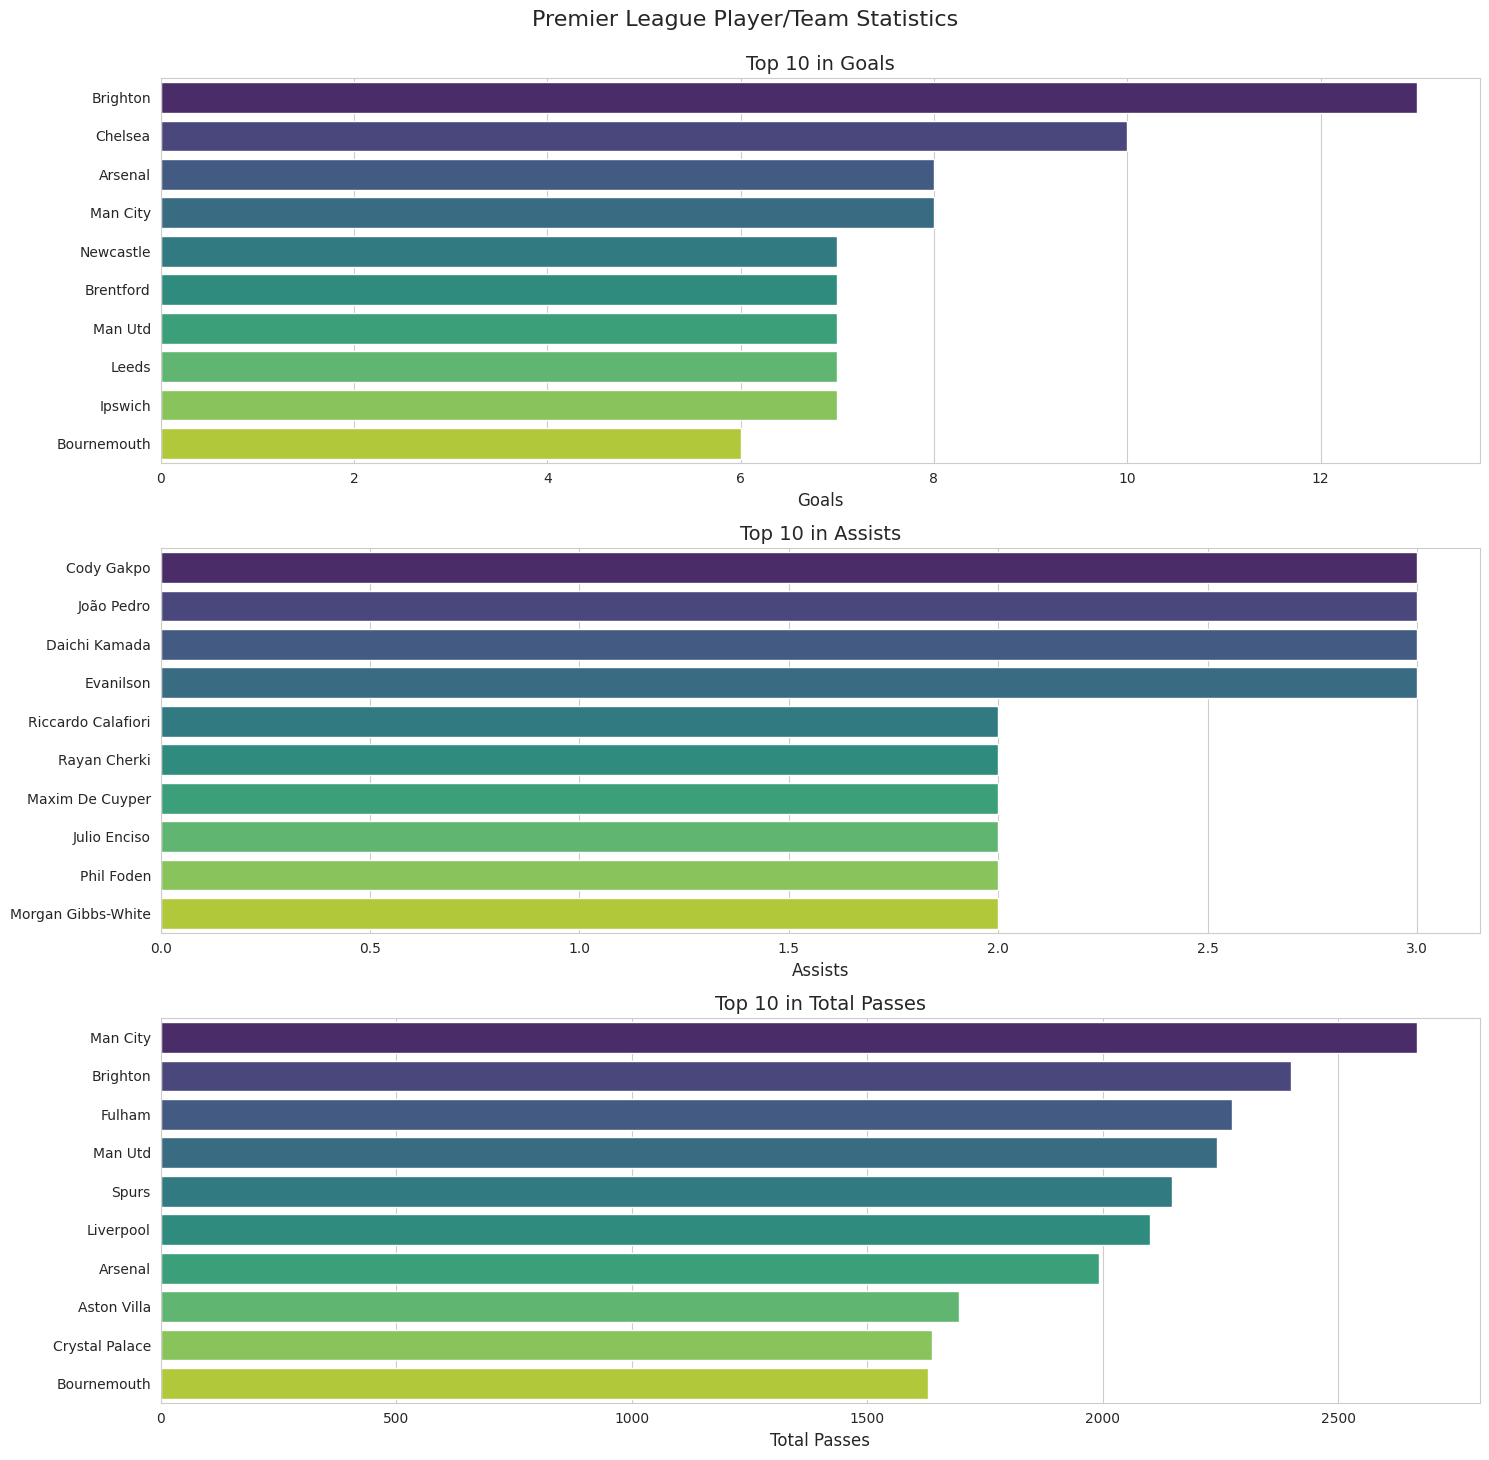

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Value' column is numeric for plotting
df_stats['Value'] = pd.to_numeric(df_stats['Value'].str.replace(',', ''), errors='coerce')

# Drop any rows where Value could not be converted to numeric (if any)
df_stats.dropna(subset=['Value'], inplace=True)

# Set style for plots
sns.set_style("whitegrid")

# Get unique categories
categories = df_stats['Category'].unique()

plt.figure(figsize=(15, 15))

for i, category in enumerate(categories):
    plt.subplot(len(categories), 1, i + 1)

    # Filter data for the current category and sort by Value
    category_df = df_stats[df_stats['Category'] == category].sort_values(by='Value', ascending=False).head(10)

    # For 'Total Passes', 'Player' column actually contains team names, rename for clarity
    if category == 'Total Passes':
        plot_labels = category_df['Player'] # Use 'Player' column which has team names
    else:
        plot_labels = category_df['Player']

    sns.barplot(x='Value', y=plot_labels, data=category_df, palette='viridis')
    plt.title(f'Top 10 in {category}', fontsize=14)
    plt.xlabel(category, fontsize=12)
    plt.ylabel('') # Remove y-label as names are self-explanatory
    plt.tight_layout()

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.suptitle('Premier League Player/Team Statistics', fontsize=16, y=1.00)
plt.show()